In [1]:
from keras.layers import Lambda, Input, Dense, Reshape, Dropout, Conv2D, Flatten
from keras.models import Model
from keras.losses import mse, binary_crossentropy
from keras.utils import plot_model

from keras.metrics import categorical_crossentropy

import tensorflow as tf
from tensorflow.keras import backend as K

from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, mean_squared_error

import pandas as pd
import numpy as np
import xarray as xr

from scipy import stats
import xesmf as xe
from math import ceil

import matplotlib
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import seaborn as sns

import clustering_functions as cf
import skill_functions as sf
import preprocessing_functions as pf

%load_ext autoreload
%autoreload 2

2026-05-29 11:48:26.318934: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-29 11:48:26.360689: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-29 11:48:26.360723: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-29 11:48:26.360730: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-29 11:48:26.367595: I tensorflow/core/platform/cpu_feature_g

In [2]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]

In [3]:
SCRATCH = "/net/helium/atmosdyn/qnicolas/"
RESULTS_PATH = SCRATCH + "C4E/results/"
DATA_PATH = "/net/helium/atmosdyn/vselvakumar/Data/C4E/data_pub/"

# Parameters

In [4]:
import yaml
from yaml import CLoader as Loader


filepath = RESULTS_PATH + "cmmvae/"


In [5]:
# sampling function

def sampling(args):
    z_mean, z_log_sigma = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], K.int_shape(z_mean)[1]), mean=0., stddev=1.)
    return z_mean + K.exp(0.5*z_log_sigma) * epsilon

# Data pre-processing

In [6]:
z500 = pf.preprocess_dataset(filename = DATA_PATH + 'era5_z500_daily_250_atlantic_1940_2022.nc',
                              variable_name = 'z', 
                              multiplication_factor = 1/g0, 
                              geographical_filter = 'new atlantic', 
                              months_filter = extended_winter_months, 
                              anomalies = True, 
                              normalization = False,
                              rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
z500 = z500/z500.std()

z500_reshaped = cf.reshape_data_for_clustering(z500)

## QN: caculate kmeans for chirps

In [30]:
 from sklearn.cluster import KMeans

pr_chirps = pf.preprocess_dataset(filename = DATA_PATH + "CHIRPS_morocco_1980_2022.nc",
                              variable_name = 'precipitation_amount', 
                              multiplication_factor = 1, 
                              geographical_filter = '', 
                              months_filter = extended_winter_months, 
                              anomalies = False, 
                              normalization = False,
                              rolling_window = 3)
pr_chirps = pr_chirps.isel(time=slice(None,-1))

pr_chirps_ar = cf.reshape_data_for_clustering(pr_chirps)
nan_mask = np.isnan(pr_chirps_ar[0])
pr_chirps_ar_nonan = pr_chirps_ar[:,~nan_mask]

Geographical filter not recognized, no filter applied


In [54]:
# Takes 1-2 min
clusters = KMeans(n_clusters=5, n_init=50, random_state=0).fit(pr_chirps_ar_nonan)


In [107]:
import cartopy.feature as cfeature

def plot_cluster_map(cluster_num,ax):
    cluster1 = clusters.cluster_centers_[cluster_num]
    cluster1_map = np.zeros(test.shape[1]) * np.nan
    cluster1_map[~nan_mask] = cluster1
    cluster1_map = cluster1_map.reshape(pr_chirps.shape[1:][::-1])
    cluster1_map = xr.DataArray(cluster1_map, dims = ['longitude','latitude'],coords = {'latitude':pr_chirps.coords['latitude'],
                                                                                        'longitude':pr_chirps.coords['longitude']
                                                                                       } )
    cluster1_map.plot(ax=ax,x='longitude',cmap='GnBu',levels = np.arange(0,41,5), transform = ccrs.PlateCarree(),cbar_kwargs = {'orientation':'horizontal'})

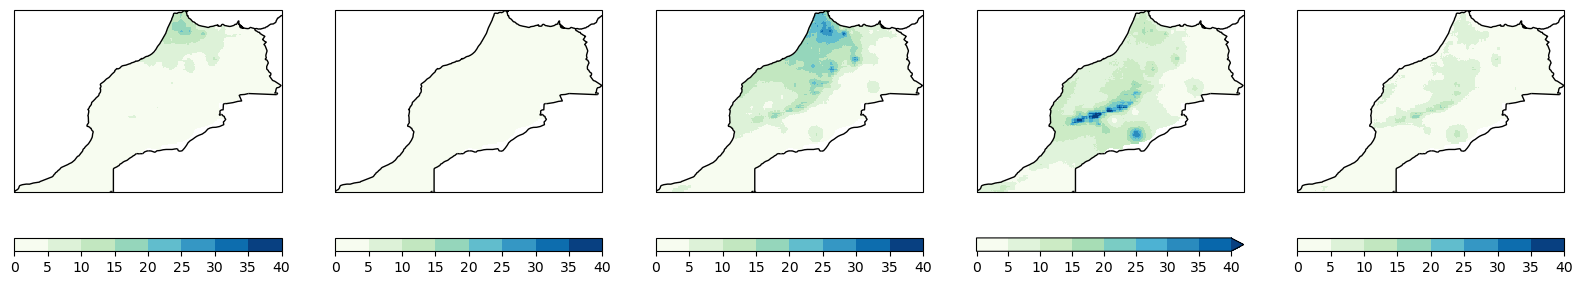

In [108]:
_,axs = plt.subplots(1,5,figsize=(20,4), subplot_kw = {'projection':ccrs.PlateCarree()})
permut = [1,0,4,3,2]
for i,ax in enumerate(axs):
    plot_cluster_map(permut[i],ax)
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)

In [154]:
# save clusters
cluster_labels = clusters.predict(pr_chirps_ar_nonan)
label_indices_ = (cluster_labels[:,None] == np.arange(5)[None,:]) * 1

In [146]:
d = {'labels': np.concatenate([cluster_labels, [np.nan]])}
df = pd.DataFrame(data=d)
df.to_csv(SCRATCH + 'C4E/CHIRPS_pr_cluster_labels_5.csv')

## Initial code from Fiona

In [7]:
# CHIRPS

pr_labels = pd.read_csv(SCRATCH + 'C4E/CHIRPS_pr_cluster_labels_5.csv')
pr_labels.columns = ['index', 'labels']
pr_labels.drop(pr_labels.tail(1).index,inplace=True)

pr_labels['values']=[1]*len(pr_labels)
pr_labels['labels'] = pr_labels['labels'].astype(np.int32)

label_indices_pd = pd.pivot_table(pr_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
label_indices = label_indices_pd.values

pr_spatial_ = pf.preprocess_dataset(filename = DATA_PATH + "CHIRPS_morocco_1980_2022.nc",
                              variable_name = 'precipitation_amount', 
                              multiplication_factor = 1, 
                              geographical_filter = '', 
                              months_filter = extended_winter_months, 
                              anomalies = False, 
                              normalization = False,
                              rolling_window = 3)
pr_spatial_ = pr_spatial_.where(pr_spatial_['time.year'] < 2023, drop=True)

threshold_qn95 = pr_spatial_ > pr_spatial_.quantile(0.95, dim='time')

pr_spatial = pr_spatial_.mean(('latitude','longitude'))


# threshold_qn95 = xr.open_dataset(DATA_PATH + 'CHIRPS_pr_95pc_EW.nc')
# threshold_qn95 = threshold_qn95.where(threshold_qn95['time.year'] < 2023, drop=True)['precipitation_amount']

# pr_spatial = xr.open_dataset(DATA_PATH + 'CHIRPS_pr_total_EW.nc')['precipitation_amount']
# pr_spatial = pr_spatial.where(pr_spatial['time.year'] < 2023, drop=True)

Geographical filter not recognized, no filter applied


/home/qnicolas/.conda/envs/cmmvae/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


# Define model

## Functions

In [10]:

def set_encoder(cluster_number, verbose = True, latent_dim = 15, layer_dims = (825,256,128,64), pr_cluster_number = 5):
    original_dim, dim_layer1, dim_layer2, dim_layer3 = layer_dims

    activation_function = 'relu'
    
    input_shape = (original_dim, )
    input_shape_r = (pr_cluster_number, )

    inputs_x = Input(shape=input_shape, name='encoder_input')
    inputs_r = Input(shape=input_shape_r, name='ground_truth')
    
    inter_x1 = Dense(dim_layer1, activation=activation_function, name='encoder_intermediate')(inputs_x)
    inter_x2 = Dense(dim_layer2, activation=activation_function, name='encoder_intermediate_2')(inter_x1)
    inter_x3 = Dense(dim_layer3, activation=activation_function, name='encoder_intermediate_3')(inter_x2)
    
    dummy = Input(shape=(1,), name='dummy')
    mu_vector = Dense(cluster_number*latent_dim, name='mu_vector',use_bias=False)(dummy)
    mu = Reshape((cluster_number,latent_dim), name='mu')(mu_vector)
    
    pi = Dense(cluster_number, activation='softmax', name='pi')(dummy)
    c = Dense(cluster_number, activation='softmax', name='c')(inter_x3)
    
    z_mean = Dense(latent_dim, name='z_mean')(inter_x3)
    z_log_var = Dense(latent_dim, name='z_log_var')(inter_x3)
    
    r = Dense(pr_cluster_number, name='r_label', activation='softmax')(inter_x3)
    
    cr = Dense(cluster_number, activation='softmax', name='cr')(r)
    
    z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])
    
    encoder = Model([inputs_x,dummy, inputs_r], [z_mean, z_log_var, z, mu, c, pi, r, cr], name='encoder')

    if verbose:
        encoder.summary()
        plot_model(encoder, show_shapes=True, dpi=100)
        plot_model(encoder, to_file=filepath+'encoder_graph.png', show_shapes=True, dpi=100)
    return encoder, inputs_x, dummy, inputs_r, c, cr, r, z_mean, z_log_var, mu, pi


**Decoder**

In [11]:
def set_decoder(latent_dim = 15, layer_dims = (825,256,128,64), verbose = True):
    original_dim, dim_layer1, dim_layer2, dim_layer3 = layer_dims

    activation_function = 'relu'

    latent_inputs = Input(shape=(latent_dim,), name='z_sampling')

    inter_y1 = Dense(dim_layer3, activation=activation_function)(latent_inputs)
    inter_y2 = Dense(dim_layer2, activation=activation_function)(inter_y1)
    inter_y3 = Dense(dim_layer1, activation=activation_function)(inter_y2)

    outputs = Dense(original_dim)(inter_y3)

    decoder = Model(latent_inputs, outputs, name='decoder')

    if verbose:
        decoder.summary()
        plot_model(decoder, show_shapes=True, dpi=100)
        plot_model(decoder, to_file=filepath+'decoder_graph.png', show_shapes=True, dpi=100)
    return decoder, outputs

**combine encoder and decoder to VAE model and print summary**

In [12]:
def set_loss(cluster_number, inputs_x, outputs, c, cr, inputs_r, r, z_mean, z_log_var, mu, pi, reconstruction_loss_factor=.5, original_dim=825, pr_cluster_number = 5, batch_size = 128):
    reconstruction_loss = mse(inputs_x, outputs)*original_dim*reconstruction_loss_factor

    prediction_loss = categorical_crossentropy(c, cr)

    # Second term is an entropy regularizer: forces model to give confident predictions about the precip cluster
    # QN: MAY NEED TO ADD A MINUS IN FRONT OF THE SECOND TERM
    target_loss = (categorical_crossentropy(inputs_r, r) + categorical_crossentropy(r, r))*pr_cluster_number  

    kl_loss_all = tf.compat.v1.get_variable("kl_loss_all", [batch_size,1], 
                                    dtype=tf.float32,initializer=tf.zeros_initializer)

    kl_cat_all = tf.compat.v1.get_variable("kl_cat_all", [batch_size,1], 
                                    dtype=tf.float32,initializer=tf.zeros_initializer)
    dir_prior_all = tf.compat.v1.get_variable("dir_prior_all", [batch_size,1], 
                                    dtype=tf.float32,initializer=tf.zeros_initializer)

    for i in range(0,cluster_number):
        
        kl_loss = 1 + z_log_var - tf.math.square(z_mean-mu[:,i,:]) - tf.math.exp(z_log_var)
        kl_loss = tf.multiply(tf.reduce_sum(kl_loss, axis=-1), c[:,i])
        kl_loss = -0.5*(kl_loss)
        kl_loss_all = kl_loss_all + kl_loss
        
        mc = tf.reduce_mean(c[:,i])
        mpi = tf.reduce_mean(pi[:,i])
        kl_cat = mc * tf.math.log(mc)- mc * tf.math.log(mpi)
        kl_cat_all = kl_cat_all+kl_cat
        
        dir_prior = -tf.math.log(pi[:,i])*0.5
        dir_prior_all = dir_prior_all + dir_prior
    vae_loss = K.mean(reconstruction_loss+prediction_loss+target_loss+kl_loss_all+kl_cat_all+dir_prior_all)
    return vae_loss


def set_vae(cluster_number, verbose = True, latent_dim = 15, layer_dims = (825,256,128,64), pr_cluster_number = 5, reconstruction_loss_factor=.5, batch_size = 128):
    encoder, inputs_x, dummy, inputs_r, c, cr, r, z_mean, z_log_var, mu, pi = set_encoder(cluster_number, verbose, latent_dim, layer_dims)
    decoder, outputs = set_decoder(latent_dim, layer_dims, verbose)
    outputs = decoder(encoder([inputs_x, dummy, inputs_r])[2])

    vae = Model([inputs_x,dummy, inputs_r], outputs, name='vae_classification')

    loss = set_loss(cluster_number, inputs_x, outputs, c, cr, inputs_r, r, z_mean, z_log_var, mu, pi, 
                    reconstruction_loss_factor = reconstruction_loss_factor, original_dim = layer_dims[0], pr_cluster_number = pr_cluster_number, batch_size = batch_size)
    
    vae.add_loss(loss)
    vae.compile(optimizer='adam')

    if verbose:
        vae.summary()

    return vae, encoder



## Define

In [13]:
cluster_number = 7
vae, encoder = set_vae(cluster_number, verbose = False, latent_dim = 15, layer_dims = (825,256,128,64), pr_cluster_number = 5, reconstruction_loss_factor=.5)
vae.save_weights(filepath+'random_weights_'+str(cluster_number)+'.h5')

# Train model 

In [15]:
X = cf.reshape_data_for_clustering(z500)
y = label_indices
dummy_full = np.ones((X.shape[0],1))

epochs = 150
batch_size = 128

**Test convergence of loss function**

Epoch 1/150
35/35 [==============================] - 5s 33ms/step - loss: 348.0510 - val_loss: 223.6263
Epoch 2/150
35/35 [==============================] - 1s 19ms/step - loss: 195.4510 - val_loss: 169.6880
Epoch 3/150
35/35 [==============================] - 1s 19ms/step - loss: 154.8904 - val_loss: 143.6650
Epoch 4/150
35/35 [==============================] - 1s 19ms/step - loss: 135.0795 - val_loss: 133.5230
Epoch 5/150
35/35 [==============================] - 1s 21ms/step - loss: 124.4095 - val_loss: 121.1416
Epoch 6/150
35/35 [==============================] - 1s 21ms/step - loss: 115.1765 - val_loss: 116.0865
Epoch 7/150
35/35 [==============================] - 1s 21ms/step - loss: 106.7716 - val_loss: 103.4719
Epoch 8/150
35/35 [==============================] - 1s 21ms/step - loss: 97.7847 - val_loss: 96.6062
Epoch 9/150
35/35 [==============================] - 1s 21ms/step - loss: 91.9885 - val_loss: 90.8063
Epoch 10/150
35/35 [==============================] - 1s 21ms/step -

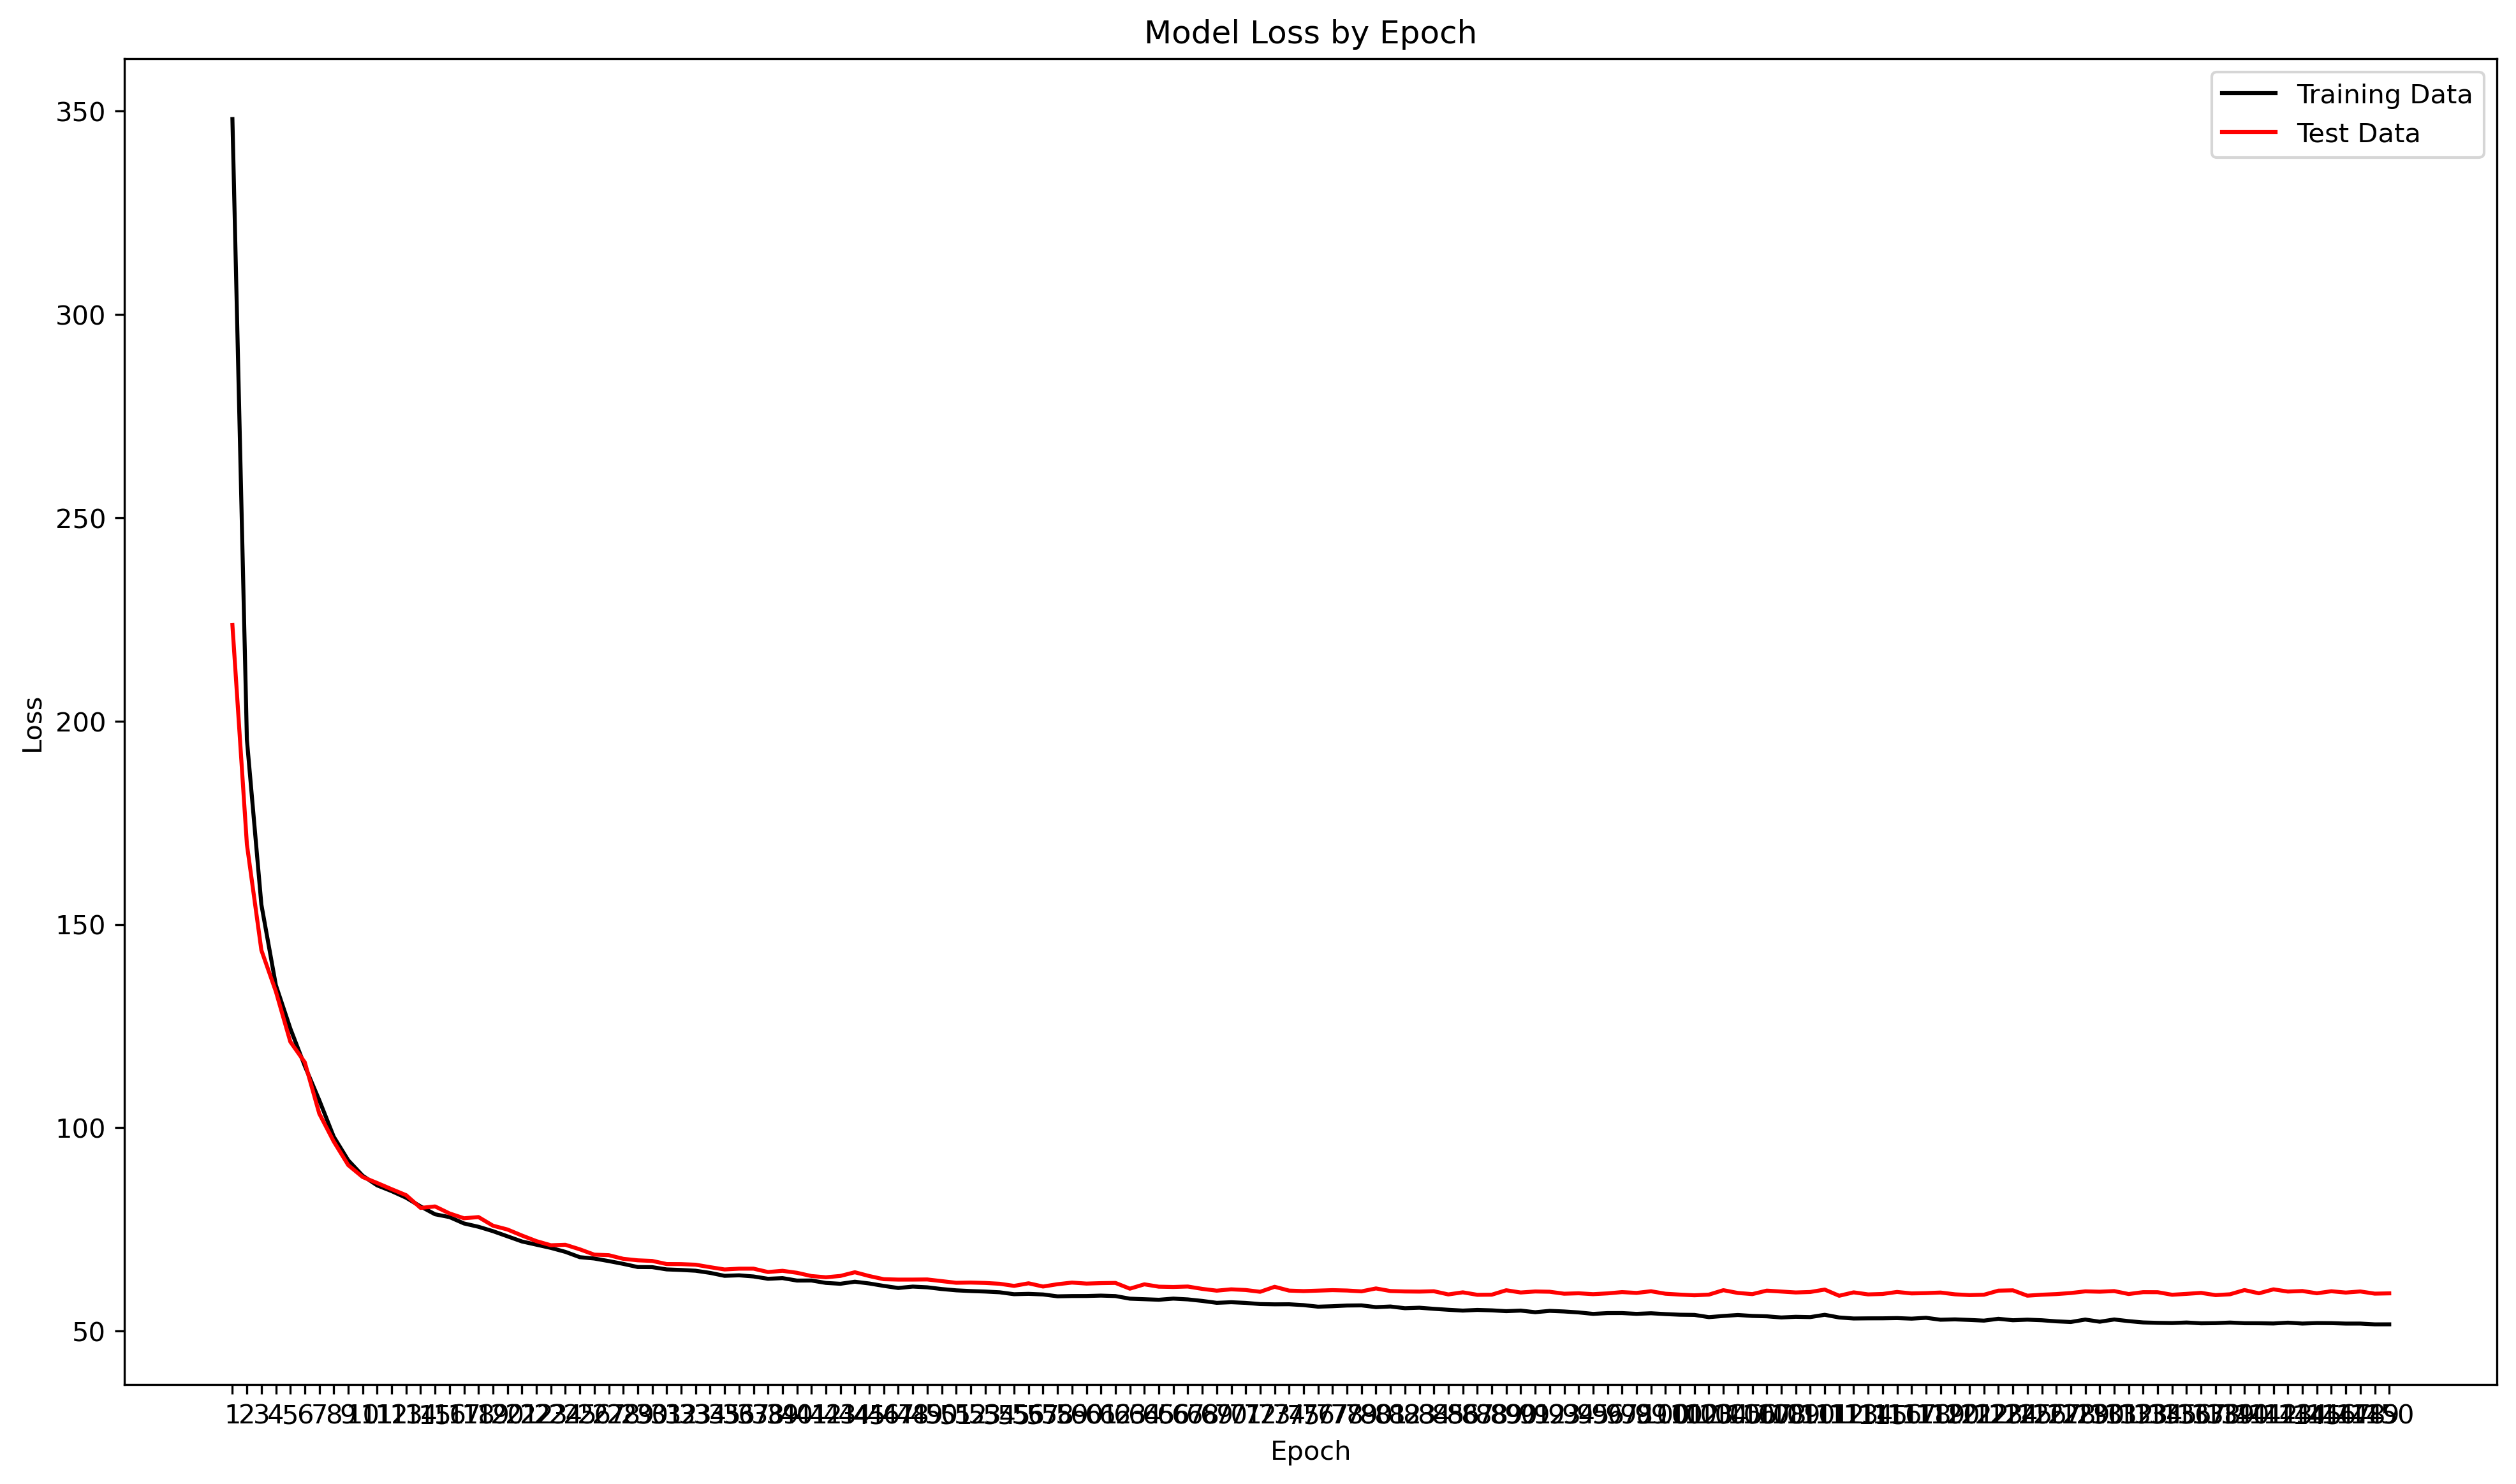

CPU times: user 10min 52s, sys: 2min 9s, total: 13min 1s
Wall time: 1min 57s


In [31]:
%%time
X_train_1, X_test_1, y_train, y_test = train_test_split(z500.values, y, test_size=0.3)

nt,ny,nx = X_train_1.shape
X_train = np.reshape(X_train_1, [nt, ny*nx], order='F')

nt,ny,nx = X_test_1.shape
X_test = np.reshape(X_test_1, [nt, ny*nx], order='F')

dummy_train = np.ones((X_train.shape[0],1))
dummy_test = np.ones((X_test.shape[0],1))

vae.load_weights(filepath+'random_weights_'+str(cluster_number)+'.h5')

history = vae.fit([X_train, dummy_train, y_train], [X_train, dummy_train, y_train], epochs=epochs, 
                  batch_size=batch_size, 
                  validation_data=([X_test,dummy_test,y_test], [X_test,dummy_test,y_test]))
fig, ax = plt.subplots(figsize=(16,9), dpi=300)
plt.title(label='Model Loss by Epoch', loc='center')

ax.plot(history.history['loss'], label='Training Data', color='black')
ax.plot(history.history['val_loss'], label='Test Data', color='red')
ax.set(xlabel='Epoch', ylabel='Loss')
plt.xticks(ticks=np.arange(len(history.history['loss']), step=1), labels=np.arange(1, len(history.history['loss'])+1, step=1))
plt.legend()
plt.show()

In [33]:
vae.save_weights(filepath+'final_weights_'+str(cluster_number)+'_single'+'.h5')

## Cross-validation of model

In [ ]:
%%time
for count in range(20):
    
    X_train_1, X_test_1, y_train, y_test = train_test_split(z500.values, y, test_size=0.3)

    nt,ny,nx = X_train_1.shape
    X_train = np.reshape(X_train_1, [nt, ny*nx], order='F')

    nt,ny,nx = X_test_1.shape
    X_test = np.reshape(X_test_1, [nt, ny*nx], order='F')

    dummy_train = np.ones((X_train.shape[0],1))
    dummy_test = np.ones((X_test.shape[0],1))

    vae.load_weights(filepath+'random_weights_'+str(cluster_number)+'.h5')

    history = vae.fit([X_train, dummy_train, y_train], [X_train, dummy_train, y_train], epochs=epochs, 
                      batch_size=batch_size, 
                      validation_data=([X_test,dummy_test,y_test], [X_test,dummy_test,y_test]))
    
    vae.save_weights(filepath+'final_weights_'+str(cluster_number)+'_'+str(count)+'.h5')

Epoch 1/150
35/35 [==============================] - 1s 22ms/step - loss: 375.6747 - val_loss: 261.0259
Epoch 2/150
35/35 [==============================] - 1s 20ms/step - loss: 212.0051 - val_loss: 197.1532
Epoch 3/150
35/35 [==============================] - 1s 20ms/step - loss: 167.2266 - val_loss: 145.0288
Epoch 4/150
35/35 [==============================] - 1s 21ms/step - loss: 133.8776 - val_loss: 126.2877
Epoch 5/150
35/35 [==============================] - 1s 21ms/step - loss: 121.1344 - val_loss: 117.1252
Epoch 6/150
35/35 [==============================] - 1s 20ms/step - loss: 114.9596 - val_loss: 115.5808
Epoch 7/150
35/35 [==============================] - 1s 21ms/step - loss: 111.0851 - val_loss: 107.6827
Epoch 8/150
35/35 [==============================] - 1s 21ms/step - loss: 102.7486 - val_loss: 99.9582
Epoch 9/150
35/35 [==============================] - 1s 21ms/step - loss: 94.9677 - val_loss: 93.4183
Epoch 10/150
35/35 [==============================] - 1s 21ms/step 

# Evaluation pipeline

In [43]:
chosen_count = 17
vae.load_weights(filepath+'final_weights_'+str(cluster_number)+'_'+str(chosen_count)+'.h5')

[z_mean_enc, z_log_var_enc, z_enc, mu_enc, c_enc, pi_enc, r_enc, cr_enc] = encoder.predict([X,dummy_full, y],batch_size=batch_size)

50/50 [==============================] - 0s 5ms/step


In [44]:
final_labels = np.zeros(X.shape[0])
for i in range(0, X.shape[0]):
    max_prob = np.max(c_enc[i,:])
    idx = np.argmax(c_enc[i,:])
    final_labels[i] = idx

In [45]:
# re-order labels

precip_sum = pd.DataFrame(pr_spatial.values[:6352]).groupby(final_labels).sum().reset_index()
precip_sum['index']=precip_sum['index'].astype('int')
precip_sum = precip_sum.rename(columns={"index": "index_old"})
precip_sum = precip_sum.sort_values(by=0, ascending=False)
precip_sum['index_new'] = np.arange(precip_sum.shape[0])

labels_reordered = final_labels.copy()

for i in range(len(final_labels)):
    
    new_label = precip_sum[precip_sum['index_old']==final_labels[i].astype('int')]['index_new'].values[0]
    
    labels_reordered[i] = new_label
    
precip_sum['index_old'].values.tolist()

[4, 5, 2, 0, 1, 3, 6]

In [46]:
# get cluster centers

z500_labels_preciporder = z500.assign_coords(label=("time", labels_reordered))/weights
z500_labels = z500.assign_coords(label=("time", final_labels))/weights

means_preciporder = z500_labels_preciporder.groupby('label').mean()
means = z500_labels.groupby('label').mean()

In [140]:
df = pd.DataFrame(data=c_enc)
df['label'] = final_labels
#df.to_csv(filepath+'cluster_probabilities_'+str(cluster_number)+'.csv')

print('calculating skill score')

bss_95 = sf.calculate_95pc_skill_score_probabilistic(cluster_number_z500 = cluster_number, 
                                                  z500_cluster_probabilities = c_enc, 
                                                  pr_spatial = pr_spatial)

print(bss_95)

calculating skill score
0.07966405401002441


In [141]:
precip_odds_ratio = cf.calculate_conditional_probability_change_label(threshold_matrix = threshold_qn95, 
                                                        labels=final_labels,
                                                       comparison = 'ratio', shift_value=0)
p95_per_regime = 0.05 * precip_odds_ratio

pred_from_regime = p95_per_regime.values[final_labels.astype(np.int32)]
brier_score = ((pred_from_regime - threshold_qn95)**2).mean()

pred_from_climatology = pred_from_regime[0] * 0 + 0.05
brier_score_climatology = ((pred_from_climatology - threshold_qn95)**2).mean()

brier_skill_score = 1 - brier_score/brier_score_climatology
print(brier_skill_score)

<xarray.DataArray 'precipitation_amount' ()>
array(0.04840365)
Coordinates:
    quantile  float64 0.95


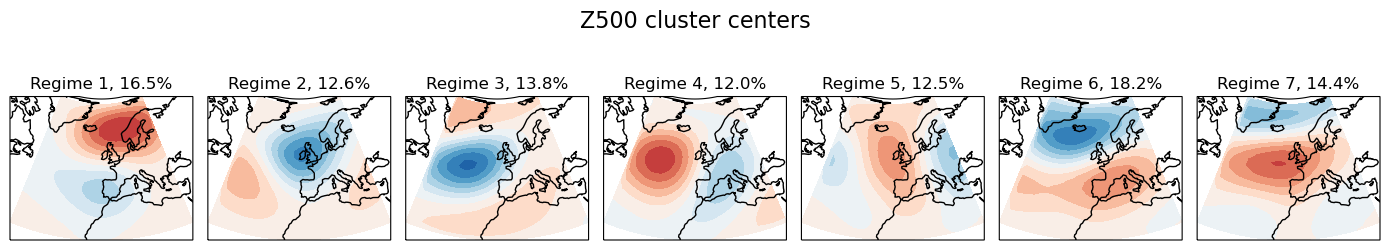

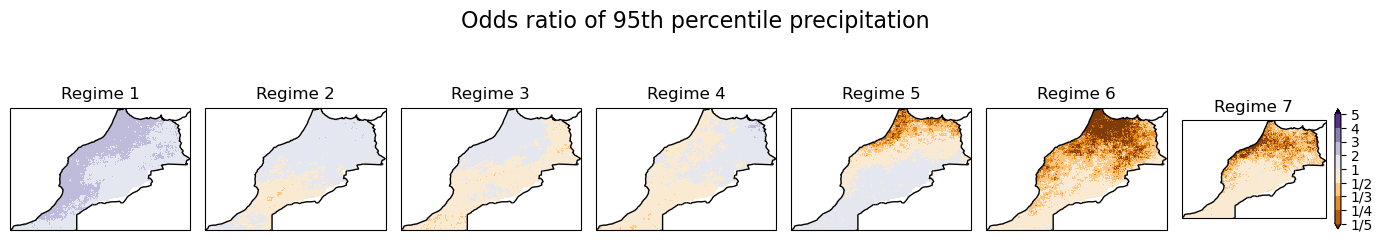

In [42]:
cluster_centers_vis = cf.visualise_contourplot(cluster_centers = means_preciporder, unit = '[m]', 
                                            regime_names = ['Regime 1', 'Regime 2', 'Regime 3',
                                                                         'Regime 4', 'Regime 5', 'Regime 6',
                                                                         'Regime 7', 'Regime 8', 'Regime 9', 'Regime 10'], 
                                             vmin=-4, vmax=4.5, steps=0.5, 
                                             color_scheme = 'RdBu_r', 
                                             plot_title = 'Z500 cluster centers',
                                                      labels_data = X, labels=labels_reordered,
                                                      borders=False, 
                                                     col_number=cluster_number, projection = ccrs.AlbersEqualArea(central_longitude=-10, central_latitude=50))

pr_qn95_ratio = cf.calculate_conditional_probability_change_label(threshold_matrix = threshold_qn95, 
                                                        labels=labels_reordered,
                                                       comparison = 'ratio', shift_value=0)

pr_qn95_vis = cf.visualise_spatial_oddsratio(dataset_xarray = pr_qn95_ratio, 
                                   color_scheme = 'PuOr', vmax=5, 
                                   title = 'Odds ratio of 95th percentile precipitation',
                                             regime_names = ['Regime 1', 'Regime 2', 'Regime 3',
                                                                         'Regime 4', 'Regime 5', 'Regime 6',
                                                                         'Regime 7', 'Regime 8', 'Regime 9', 'Regime 10'],
                                   borders=True, projection=ccrs.PlateCarree(central_longitude=0), 
                                               col_number=cluster_number)


### Fast BSS for all realizations

In [135]:
for chosen_count in range(20):
    vae.load_weights(filepath+'final_weights_'+str(cluster_number)+'_'+str(chosen_count)+'.h5')

    [z_mean_enc, z_log_var_enc, z_enc, mu_enc, c_enc, pi_enc, r_enc, cr_enc] = encoder.predict([X,dummy_full, y],batch_size=batch_size)
    final_labels = np.zeros(X.shape[0])
    for i in range(0, X.shape[0]):
        max_prob = np.max(c_enc[i,:])
        idx = np.argmax(c_enc[i,:])
        final_labels[i] = idx

    precip_odds_ratio = cf.calculate_conditional_probability_change_label(threshold_matrix = threshold_qn95, 
                                                            labels=final_labels,
                                                        comparison = 'ratio', shift_value=0)
    p95_per_regime = 0.05 * precip_odds_ratio

    pred_from_regime = p95_per_regime.values[final_labels.astype(np.int32)]
    brier_score = ((pred_from_regime - threshold_qn95)**2).mean()

    pred_from_climatology = pred_from_regime[0] * 0 + 0.05
    brier_score_climatology = ((pred_from_climatology - threshold_qn95)**2).mean()

    brier_skill_score = 1 - brier_score/brier_score_climatology
    brier_skill_score = brier_skill_score.values
    print(f"Run {chosen_count}: Brier Skill Score = {brier_skill_score}")

50/50 [==============================] - 0s 6ms/step
Run 0: Brier Skill Score = 0.03026193699860913
50/50 [==============================] - 0s 5ms/step
Run 1: Brier Skill Score = 0.04071020902913913
50/50 [==============================] - 0s 5ms/step
Run 2: Brier Skill Score = 0.023618574523476377
50/50 [==============================] - 0s 5ms/step
Run 3: Brier Skill Score = 0.03374430610823953
50/50 [==============================] - 0s 5ms/step
Run 4: Brier Skill Score = 0.03461315992360925
50/50 [==============================] - 0s 5ms/step
Run 5: Brier Skill Score = 0.0344966045497308
50/50 [==============================] - 0s 5ms/step
Run 6: Brier Skill Score = 0.029204427458364268
50/50 [==============================] - 0s 5ms/step
Run 7: Brier Skill Score = 0.030365632362534423
50/50 [==============================] - 0s 5ms/step
Run 8: Brier Skill Score = 0.017776158991383628
50/50 [==============================] - 0s 5ms/step
Run 9: Brier Skill Score = 0.031599343803880